In [ ]:
import tomllib
from pathlib import Path
import pandas as pd

RUNS = 'runs'
PREFIX = 'graphene_tiltq'          # <crystal.name>_<calculation.ID> (without the _NN of a sweep)

# sweep table written by executeTB.py: one row per calculation, one column per swept key.
# A single calculation (no sweep) has no table: it is treated as a sweep of one row and no swept keys.
sweep_path = Path(RUNS) / f'{PREFIX}_sweep.txt'
if sweep_path.exists():
    sweep = pd.read_csv(sweep_path, sep='\t', comment='#')
else:
    sweep = pd.DataFrame({'index': [0], 'name': [PREFIX]})
swept_keys = [k for k in sweep.columns if k not in ('index', 'name')]

# full input of every calculation, from its runs/<name>.toml (same order as the rows of sweep)
#   e.g. configs[i]['Field']['lambda']
configs = []
for name in sweep['name']:
    with open(Path(RUNS) / f'{name}.toml', 'rb') as f:
        configs.append(tomllib.load(f))
sweep

FileNotFoundError: [Errno 2] No such file or directory: 'runs/graphene_tiltq_oscar.toml'

igauss.shape=(50,)   mask.shape=(507,)
nt=507   imask=50
accel_x.shape=(507, 5)   accel_y.shape=(507, 5)


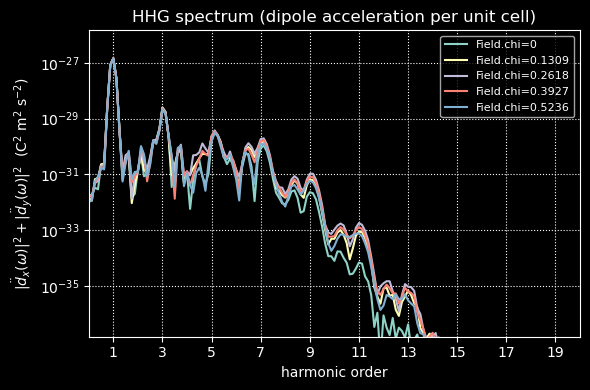

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
#plt.style.use('/home/lplaja/.matplotlib/stylelib/obsidian.mplstyle')

def gather_data(fnamelist):
    n_columns=len(fnamelist)

    t=[]
    filename=fnamelist[0]
    with open(filename, "r") as fh:  
        for line in fh:
            if line.startswith("#"):
                continue
            it, ix, iy = map(complex, line.split())
            t.append(np.real(it))

    t=np.array(t)

    n_rows=len(t)

    dipole_vel_x=np.zeros((n_rows, n_columns))
    dipole_vel_y=np.zeros((n_rows, n_columns))

    for i_file, filename in enumerate(fnamelist):

        ivel_x=[]
        ivel_y=[]
        with open(filename, "r") as fh:
            for line in fh:
                if line.startswith("#"):
                    continue
                it, ix, iy = map(complex, line.split())
                ivel_x.append(np.real(ix))
                ivel_y.append(np.real(iy))
# Caso de cambio de nt
#        if i_file==2:
#            dipole_vel_x[:,i_file]=ivel_x[::2]
#            dipole_vel_y[:,i_file]=ivel_y[::2]
#        else:
#            dipole_vel_x[:,i_file]=ivel_x
#            dipole_vel_y[:,i_file]=ivel_y
# caso dsin cambio de nt  
        dipole_vel_x[:,i_file]=ivel_x
        dipole_vel_y[:,i_file]=ivel_y       

    # dipole acceleration per unit cell, d(vd)/dt with t in s: C m/s^2
    accel_x=np.gradient(dipole_vel_x, t, axis=0)
    accel_y=np.gradient(dipole_vel_y, t, axis=0)
    accel_x=accel_x[2:-3]
    accel_y=accel_y[2:-3]

    return t, dipole_vel_x, dipole_vel_y, accel_x, accel_y

#fnamelist=['graphene_prueba_dipole_velocity_nk300.txt','graphene_prueba_dipole_velocity_nk500.txt',
#           'graphene_prueba_dipole_velocity_nk900.txt']
#labels=['nk=300','nk=500','nk=900']

#fnamelist=['graphene_tilt_oscar_0_dipole_velocity.txt','graphene_tilt_oscar_15_dipole_velocity.txt', 
#           'graphene_tilt_oscar_30_dipole_velocity.txt']
#labels=['theta=0','theta=15','theta=30']

# files and labels from the sweep table (cell above)
fnamelist=[f"{RUNS}/{name}_dipole_velocity.txt" for name in sweep['name']]
labels=[", ".join(f"{k}={r[k]:.4g}" if isinstance(r[k], float) else f"{k}={r[k]}" for k in swept_keys)
           or r['name']                    # no sweep: label = name of the calculation
        for _, r in sweep.iterrows()]
# Oscar's tilt instead of chi (tilt = 90 deg - chi):
# labels=[f"tilt={90-np.rad2deg(c):.0f}" for c in sweep['Field.chi']]


t, dipole_vel_x, dipole_vel_y, accel_x, accel_y=gather_data(fnamelist)

nt=t.size-5
imask=int(nt/10)
mask=np.ones(nt)
igauss=np.arange(0,imask)
print(f'{igauss.shape=}   {mask.shape=}')
print(f'{nt=}   {imask=}')
print(f'{accel_x.shape=}   {accel_y.shape=}')
mask[nt-imask:]*=np.exp(-(igauss/10)**2)
for nn in range(len(fnamelist)):
    accel_x[:,nn]*=mask
    accel_y[:,nn]*=mask


# Fourier transform as an integral, a(w) = int a(t) exp(-i w t) dt ~ dt * FFT:  C m/s
dt=t[1]-t[0]
FT_npts=2*accel_x.shape[0]//8
FT_accel_x=np.fft.fft(accel_x, axis=0)[:FT_npts]*dt
FT_accel_y=np.fft.fft(accel_y, axis=0)[:FT_npts]*dt


plt.rcParams['legend.fontsize'] = 8

fig, ax=plt.subplots(1,1, figsize=(6,4))

#ax[0,0].plot(t, np.real(dipole_vel_y), label=labels)
#ax[0,0].set_xlabel("t")
#ax[0,0].set_ylabel("dipole velocity")
#ax[0,0].set_title("Dipole velocity y")
#ax[0,0].legend()
#ax[0,0].grid(False)

#ax[0,1].plot(t[2:-3], np.real(accel_y), label=labels)
#ax[0,1].set_xlabel("t")
#ax[0,1].set_ylabel("acceleration")
#ax[0,1].set_title("Acceleration y")
#ax[0,1].legend()
#ax[0,1].grid(False)

# ax[0].semilogy(np.abs(FT_accel_x)**2+np.abs(FT_accel_y)**2, label=labels)
# ax[0].set_xlabel("")
# ax[0].set_ylabel("acceleration")
# ax[0].set_title("FT Acceleration")
# ax[0].legend()
# ax[0].grid(False)

# harmonic order: FFT index / duration of the record in optical periods (was a hardcoded 8)
periods = {c['time']['tfin'] - c['time']['tini'] for c in configs}
assert len(periods) == 1, "all calculations must have the same time window"
w = np.arange(len(FT_accel_y))/periods.pop()
spectrum=np.abs(FT_accel_x)**2+np.abs(FT_accel_y)**2          # C^2 m^2 / s^2
ax.semilogy(w, spectrum, label=labels)
ax.set_xlabel("harmonic order")
ax.set_ylabel(r"$|\ddot d_x(\omega)|^2+|\ddot d_y(\omega)|^2$  (C$^2$ m$^2$ s$^{-2}$)")
ax.set_title("HHG spectrum (dipole acceleration per unit cell)")
ax.legend()
ax.set_xlim(0,20)
ax.set_ylim(spectrum.max()*1e-10, spectrum.max()*10)   
ax.set_xticks(np.arange(1, 20, 2))        # 10 decades below the maximum
ax.grid(True, linestyle='dotted')

plt.tight_layout()

![image.png](attachment:image.png)